In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from wordcloud import WordCloud
from collections import Counter
from sklearn.metrics import silhouette_score
from sentence_transformers import SentenceTransformer
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import normalize, Normalizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline
import random
import warnings
import os
import services.utils as ut
import services.model as md
np.random.seed(42)
random.seed(42)

In [3]:
warnings.filterwarnings('ignore', category=UserWarning)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TRANSFORMERS_VERBOSITY'] = 'error'

In [4]:
data_df = ut.load_data('customer_support_tickets.csv')
if data_df is not None:
    print("Data loaded successfully")
print(data_df.head())

Data loaded successfully
   Ticket ID        Customer Name              Customer Email  Customer Age  \
0          1        Marisa Obrien  carrollallison@example.com            32   
1          2         Jessica Rios    clarkeashley@example.com            42   
2          3  Christopher Robbins   gonzalestracy@example.com            48   
3          4     Christina Dillon    bradleyolson@example.org            27   
4          5    Alexander Carroll     bradleymark@example.com            67   

  Customer Gender Product Purchased Date of Purchase      Ticket Type  \
0           Other        GoPro Hero       2021-03-22  Technical issue   
1          Female       LG Smart TV       2021-05-22  Technical issue   
2           Other          Dell XPS       2020-07-14  Technical issue   
3          Female  Microsoft Office       2020-11-13  Billing inquiry   
4          Female  Autodesk AutoCAD       2020-02-04  Billing inquiry   

             Ticket Subject  \
0             Product setup   

## Preprocessing

In [5]:
data_df = data_df.drop_duplicates(subset=['Ticket Description'], keep='first')
data_df.reset_index(drop=True, inplace=True)

In [6]:
data_df['text'] = data_df['Ticket Description'].fillna('')

In [7]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\{.*?\}', '', text)
    text = re.sub(r'http\S+', '', text) # remove URLs
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\b[a-zA-Z]{1,2}\b', '', text)  # remove very short words
    return text

data_df['clean_text'] = data_df['text'].apply(clean_text)
data_df['clean_text'].head()

0     having  issue with the  please assist\n\nyour...
1     having  issue with the  please assist\n\n you...
2     facing  problem with   the   not turning   wa...
3     having  issue with the  please assist\n\n you...
4     having  issue with the  please assist\n\n\nno...
Name: clean_text, dtype: str

In [8]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package punkt to /Users/liyannan/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/liyannan/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/liyannan/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [9]:
custom_words = {
    'please', 'help', 'assist', 'support', 'thanks', 'thank','soon','mentioned',
    'im', 'ive', 'us','would', 'could', 'need', 'want', 'trying',
    'tried','check', 'checked', 'make', 'made', 'get', 'getting','also',
    'use', 'using', 'used','thing', 'something', 'anything', 'everything',
    'way', 'time','issue', 'problem', 'request',
    'work', 'working', 'fine', 'available', 'recent', 'recently','facing', 'doe',
    'noticed', 'happening', 'started', 'happen','different', 'steps', 'did',
    'regards','already', 'multiple','last','times','followed', 'reviewed',
    'specific', 'possible', 'related','new', 'old','find', 'try', 'trying', 'say', 'mean',
    'name', 'email', 'price', 'one', 'add','note', 'may', 'dont', 'know','sure',
    'changes', 'performed', 'properly','original','like', 'similar','reported','doesnt',
    'sometimes', 'acts', 'works', 'ensure', 'desired', 'action', 'remains', 'life', 'seems',
    'might', 'guide', 'much', 'others',
    'heavily', 'daily', 'task',
    'affecting', 'assistance',
    'hoping','persists','didnt',
    'option', 'perform', 'recommendation', 'information', 'official',
    'solution', 'provide', 'making',
    'user', 'customer',
    'item', 'device',
    'far', 'luck','contact', 'contacted', 'occurring'
}

In [10]:
custom_words_lemma = set([lemmatizer.lemmatize(w) for w in custom_words])

def preprocess(text):
    tokens = word_tokenize(text)
    
    processed_tokens = []
    
    for word in tokens:
        lemma = lemmatizer.lemmatize(word)
        
        if lemma not in stop_words and lemma not in custom_words_lemma and len(lemma) > 2:
            processed_tokens.append(lemma)
    
    return " ".join(processed_tokens)

data_df['processed_text'] = data_df['clean_text'].apply(preprocess)

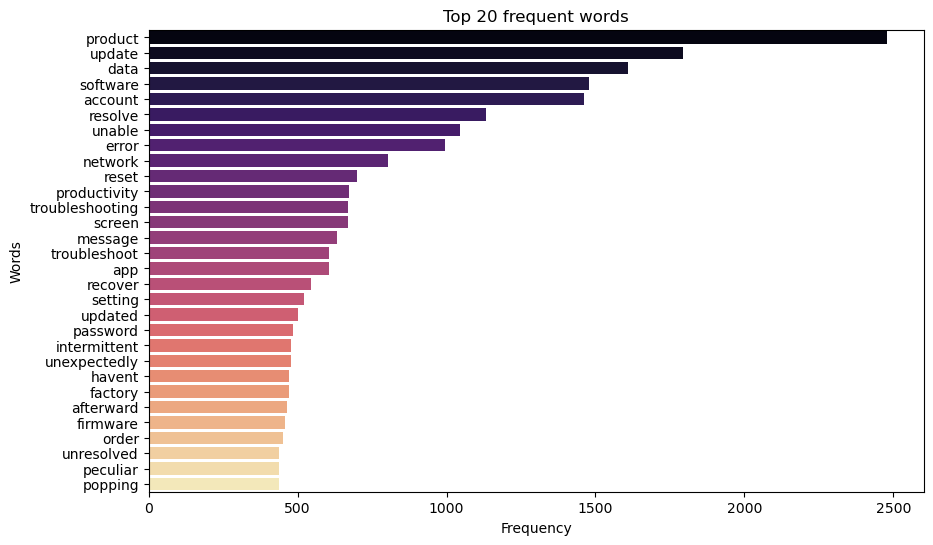

In [11]:
text_data = data_df['processed_text'].astype(str)

all_words = " ".join(text_data).lower().split()
common_words = Counter(all_words).most_common(30)

words, counts = zip(*common_words)

plt.figure(figsize=(10,6))
sns.barplot(x=list(counts), y=list(words), hue=list(words), palette='magma', legend=False)
plt.title("Top 20 frequent words")
plt.xlabel("Frequency")
plt.ylabel("Words")
plt.show()

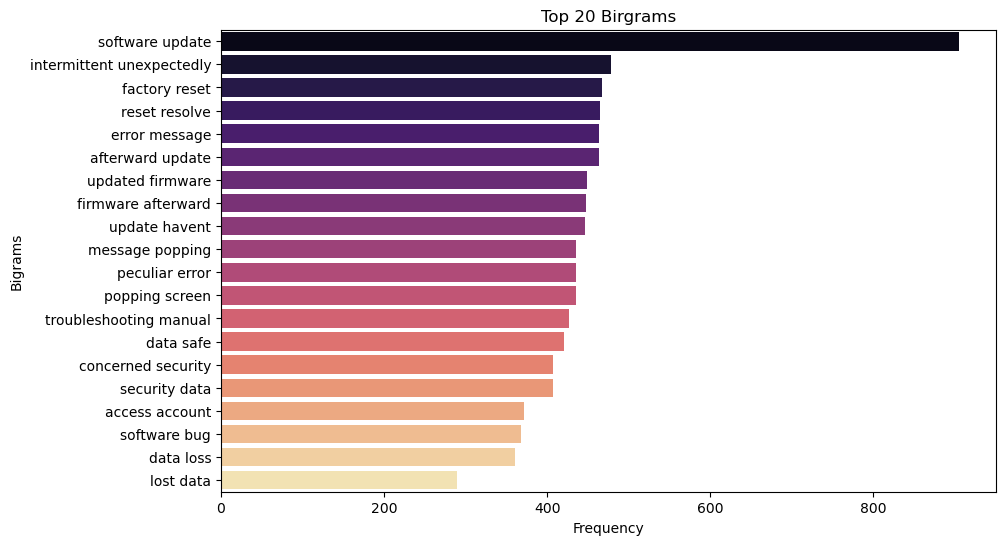

In [12]:
vectorizer = CountVectorizer(ngram_range=(2,2), stop_words='english')
x = vectorizer.fit_transform(data_df['processed_text'])
word_counts = x.sum(axis=0).A1
words = vectorizer.get_feature_names_out()
word_freq = list(zip(words, word_counts))
word_freq = sorted(word_freq, key=lambda x: x[1], reverse=True)[:20]
words, counts = zip(*word_freq)

plt.figure(figsize=(10,6))
sns.barplot(x=list(counts), y=list(words), hue=list(words), palette='magma')
plt.title("Top 20 Birgrams")
plt.xlabel("Frequency")
plt.ylabel("Bigrams")
plt.show()

In [13]:
ut.save_data(data_df, 'cleaned_data.csv')

Building the pipeline

In [14]:
def nlp_cleaner(text_list):
    results = []
    for text in text_list:
        cleaned = clean_text(text) 
        processed = preprocess(cleaned)
        results.append(processed)
    return results

### TFIDF

In [15]:
tfidf = TfidfVectorizer(max_features=1000,ngram_range=(1,2),min_df=5,max_df=0.7)

X = tfidf.fit_transform(data_df['processed_text'])

In [16]:
tfidf__preprocessing_pipeline = Pipeline([
    ('cleaner', FunctionTransformer(nlp_cleaner, validate=False)),
    ('tfidf', TfidfVectorizer(max_features=1000,ngram_range=(1,2),min_df=5,max_df=0.7))
])

### Embeddings

In [17]:
def clean_for_embeddings(text):
    text = text.lower()
    text = re.sub(r'\{.*?\}', ' ', text)
    text = re.sub(r'http\S+', ' ', text)
    text = re.sub(r"i'?m having an issue with.*?please assist\.?", ' ', text)
    text = re.sub(r'please assist\.?', ' ', text)
    text = re.sub(r'\b(id|created_at|product|price)\b', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [18]:
data_df['embedding_text'] = data_df['text'].apply(clean_for_embeddings)

In [19]:
model = SentenceTransformer('all-MiniLM-L6-v2')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [20]:
embeddings = model.encode(data_df['embedding_text'].tolist(), show_progress_bar=True)

Batches:   0%|          | 0/253 [00:00<?, ?it/s]

In [21]:
embeddings = normalize(embeddings)

In [22]:
print(cosine_similarity([embeddings[0]], [embeddings[1]]))
print(cosine_similarity([embeddings[2]], [embeddings[5]]))

[[0.33734772]]
[[0.6662934]]


Building the pipeline

In [23]:
def nlp_cleaner_embeddings(text_list):
    results = []
    for text in text_list:
        cleaned = clean_for_embeddings(text) 
        results.append(cleaned)
    return results

In [24]:
embedding_preprocessing_pipeline = Pipeline([
    ('cleaner', FunctionTransformer(nlp_cleaner_embeddings, validate=False)),
    ('embeddings', md.SentenceEmbeddingTransformer(model_name='all-MiniLM-L6-v2')),
    ('normalize', Normalizer())
])

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## Modelling

## Embedding + HAC (Kaining Yu & Yannan Li)

In this section, we apply Hierarchical Agglomerative Clustering (HAC) to sentence embeddings generated by `all-MiniLM-L6-v2`.

**Motivation:** TF-IDF represents text as sparse keyword counts and struggles to capture semantic similarity — two tickets saying *'my order hasn't arrived'* and *'package not delivered'* share few overlapping tokens but describe the same issue. Sentence embeddings encode meaning in a dense 384-dimensional space, so semantically similar tickets cluster together regardless of surface wording.

**Hypothesis:** HAC on sentence embeddings will produce semantically richer and more interpretable clusters than HAC on TF-IDF, because the dense embedding space better captures topic similarity. We use cosine distance with average linkage, since embeddings are L2-normalised and cosine distance is the natural similarity measure for this space. We compare k = 3, 5, 7 to assess stability across granularities.

In [25]:
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA


### Step 1 — Verify embeddings

We confirm that `embeddings` is L2-normalised (each row has unit norm), which means cosine similarity equals the dot product, and cosine distance = 1 − dot product. We also confirm that `data_df` and `embeddings` are row-aligned.

In [26]:
print('Embeddings shape    :', embeddings.shape)
print('dtype               :', embeddings.dtype)
print('Row norms (first 5) :',
      np.linalg.norm(embeddings[:5], axis=1).round(5))
print('Min / Max value     :',
      embeddings.min().round(4), '/', embeddings.max().round(4))
print('Any NaN?            :', np.isnan(embeddings).any())

assert len(data_df) == len(embeddings), (
    f'Mismatch: data_df has {len(data_df)} rows, '
    f'embeddings has {len(embeddings)} rows'
)
print(f'\ndata_df rows ({len(data_df)}) == '
      f'embeddings rows ({len(embeddings)})  ✓')


Embeddings shape    : (8077, 384)
dtype               : float32
Row norms (first 5) : [1. 1. 1. 1. 1.]
Min / Max value     : -0.2503 / 0.4062
Any NaN?            : False

data_df rows (8077) == embeddings rows (8077)  ✓


### Step 2 — Dendrogram (sampled)

`scipy.linkage` is O(n²) in both time and memory, so we use a random sample of 300 tickets **for visualisation only**. All quantitative evaluations are run on the full dataset via `AgglomerativeClustering`.

The dendrogram shows where the largest merge-distance gaps occur, which gives an empirical guide for choosing k.

The word embeddings have undergone L2 normalization, so the cosine similarity is equal to the dot product, thereby ensuring the stability and significance of the distance calculation.

The average connection method balances the sensitivity to noise and the compactness of clustering, and therefore is highly suitable for semantic clustering.

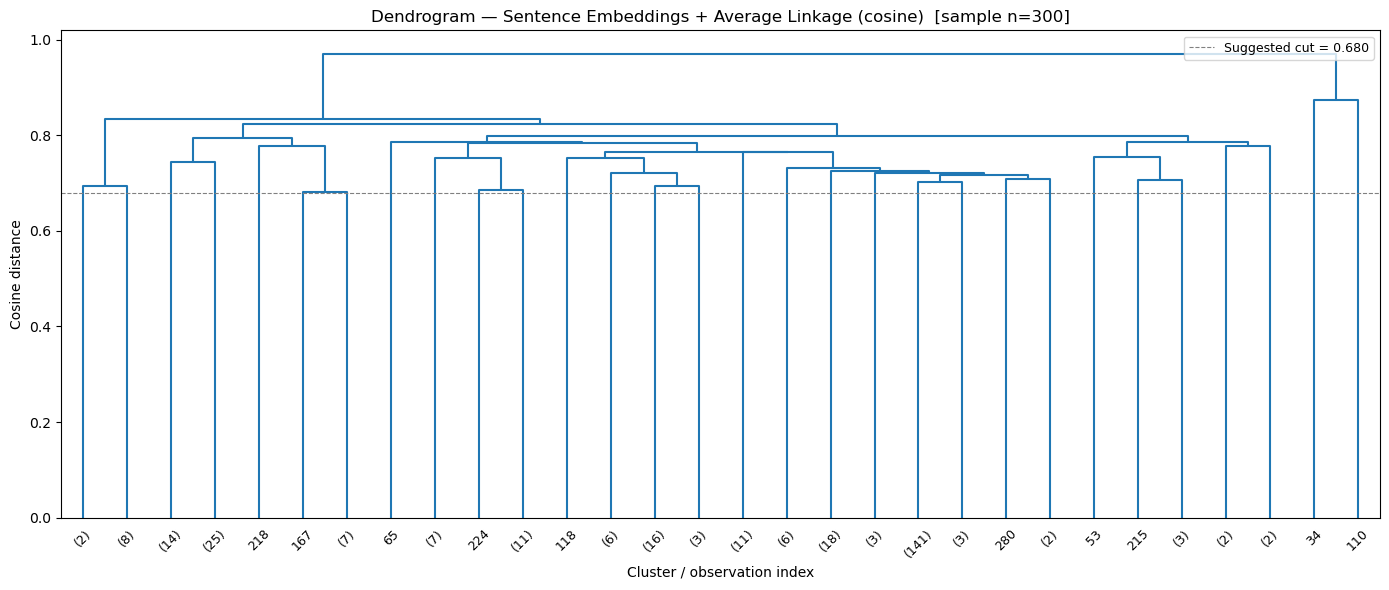

Suggested cut height: 0.6796


In [27]:
SAMPLE_SIZE = 300
rng = np.random.RandomState(42)
sample_idx = rng.choice(len(embeddings), size=SAMPLE_SIZE, replace=False)
sample_emb = embeddings[sample_idx]

# cosine distance on L2-normalised vectors = 1 - dot product
Z_emb = linkage(sample_emb, method='average', metric='cosine')
cut_height = 0.7 * max(Z_emb[:, 2])

fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(
    Z_emb,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=45,
    leaf_font_size=9,
    ax=ax,
    color_threshold=cut_height,
)
ax.axhline(
    y=cut_height, color='grey', linestyle='--', linewidth=0.8,
    label=f'Suggested cut = {cut_height:.3f}'
)
ax.set_title(
    f'Dendrogram — Sentence Embeddings + Average Linkage (cosine)  '
    f'[sample n={SAMPLE_SIZE}]',
    fontsize=12
)
ax.set_xlabel('Cluster / observation index')
ax.set_ylabel('Cosine distance')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f'Suggested cut height: {cut_height:.4f}')


### Step 3 — Choose k: Silhouette & Davies-Bouldin across k = 2…15

We evaluate the full dataset with two complementary metrics:

- **Silhouette score** (higher = better): measures how well each point fits its own cluster relative to the nearest neighbouring cluster. We pass `metric='cosine'` to match the linkage distance.
- **Davies-Bouldin index** (lower = better): ratio of within-cluster scatter to between-cluster separation. Unlike Calinski-Harabasz, it is consistent with non-Euclidean distance choices.

We look for the k where silhouette peaks and Davies-Bouldin troughs.

Scanning k = 2 … 15 on full dataset ...
  k= 2  Silhouette = 0.2277  Davies-Bouldin = 0.7874
  k= 3  Silhouette = 0.2058  Davies-Bouldin = 1.7528
  k= 4  Silhouette = 0.1807  Davies-Bouldin = 1.5150
  k= 5  Silhouette = 0.1653  Davies-Bouldin = 1.2325
  k= 6  Silhouette = 0.1427  Davies-Bouldin = 1.1629
  k= 7  Silhouette = 0.1375  Davies-Bouldin = 1.4019
  k= 8  Silhouette = 0.1293  Davies-Bouldin = 1.7694
  k= 9  Silhouette = 0.1176  Davies-Bouldin = 1.8156
  k=10  Silhouette = 0.1114  Davies-Bouldin = 1.7753
  k=11  Silhouette = 0.0987  Davies-Bouldin = 1.7553
  k=12  Silhouette = 0.0895  Davies-Bouldin = 1.8746
  k=13  Silhouette = 0.0805  Davies-Bouldin = 1.8774
  k=14  Silhouette = 0.0782  Davies-Bouldin = 2.0278
  k=15  Silhouette = 0.0732  Davies-Bouldin = 2.1149


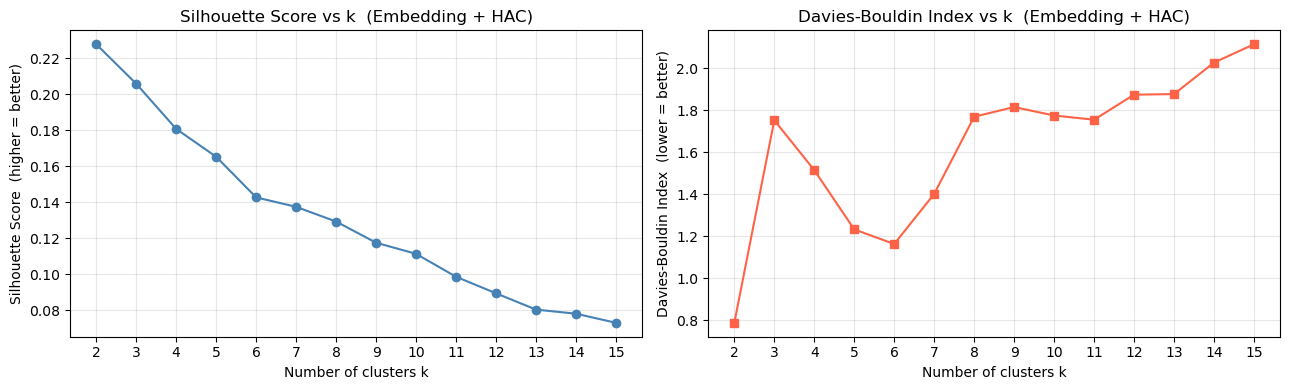


Best k by Silhouette:     2  (score = 0.2277)
Best k by Davies-Bouldin: 2  (score = 0.7874)


In [28]:
k_range = range(2, 16)
sil_scores_emb = []
db_scores_emb  = []

print('Scanning k = 2 … 15 on full dataset ...')
for k in k_range:
    hac_tmp = AgglomerativeClustering(
        n_clusters=k, metric='cosine', linkage='average'
    )
    labels_tmp = hac_tmp.fit_predict(embeddings)
    sil = silhouette_score(embeddings, labels_tmp, metric='cosine')
    db  = davies_bouldin_score(embeddings, labels_tmp)
    sil_scores_emb.append(sil)
    db_scores_emb.append(db)
    print(f'  k={k:2d}  Silhouette = {sil:.4f}  '
          f'Davies-Bouldin = {db:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(list(k_range), sil_scores_emb, marker='o', color='steelblue')
axes[0].set_title('Silhouette Score vs k  (Embedding + HAC)')
axes[0].set_xlabel('Number of clusters k')
axes[0].set_ylabel('Silhouette Score  (higher = better)')
axes[0].set_xticks(list(k_range))
axes[0].grid(alpha=0.3)

axes[1].plot(list(k_range), db_scores_emb, marker='s', color='tomato')
axes[1].set_title('Davies-Bouldin Index vs k  (Embedding + HAC)')
axes[1].set_xlabel('Number of clusters k')
axes[1].set_ylabel('Davies-Bouldin Index  (lower = better)')
axes[1].set_xticks(list(k_range))
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

best_k_sil = list(k_range)[sil_scores_emb.index(max(sil_scores_emb))]
best_k_db  = list(k_range)[db_scores_emb.index(min(db_scores_emb))]
print(f'\nBest k by Silhouette:     {best_k_sil}  '
      f'(score = {max(sil_scores_emb):.4f})')
print(f'Best k by Davies-Bouldin: {best_k_db}  '
      f'(score = {min(db_scores_emb):.4f})')


### Step 4 — Fit HAC for k = 3, 5, 7 (stability check)

We fit three k values and compare metrics. The k with the highest silhouette score is selected as `BEST_K` and stored in the primary column `emb_hac_cluster`. Comparing k = 3, 5, 7 shows whether increasing k splits existing clusters into meaningful sub-groups or simply fragments them arbitrarily.

In [ ]:
HAC_K_VALUES = [3, 5, 7]

for k in HAC_K_VALUES:
    hac_k = AgglomerativeClustering(
        n_clusters=k, metric='cosine', linkage='average'
    )
    labels = hac_k.fit_predict(embeddings)
    data_df[f'emb_hac_{k}'] = labels
    sil = silhouette_score(embeddings, labels, metric='cosine')
    db  = davies_bouldin_score(embeddings, labels)
    print(f'k={k}  |  Silhouette = {sil:.4f}  '
          f'|  Davies-Bouldin = {db:.4f}')


sil_by_k = {
    k: silhouette_score(embeddings, data_df[f'emb_hac_{k}'], metric='cosine')
    for k in HAC_K_VALUES
}
BEST_K = max(sil_by_k, key=sil_by_k.get)

data_df['emb_hac_cluster'] = data_df[f'emb_hac_{BEST_K}']
print(f'\nBest k among {HAC_K_VALUES}: {BEST_K}  '
      f'(Silhouette = {sil_by_k[BEST_K]:.4f})')
data_df[['embedding_text', 'emb_hac_cluster']].head()

k=3  |  Silhouette = 0.2058  |  Davies-Bouldin = 1.7528
k=5  |  Silhouette = 0.1653  |  Davies-Bouldin = 1.2325
k=7  |  Silhouette = 0.1375  |  Davies-Bouldin = 1.4019

Best k among [3, 5, 7]: 3  (Silhouette = 0.2058)


,embedding_text,emb_hac_cluster
0,your billing zip code is we appreciate that yo...,0
1,if you need to change an existing if the issue...,0
2,i m facing a problem with my the is not turnin...,0
3,if you have a problem you re interested in and...,0
4,note the seller is not responsible for any dam...,0


### Step 5 — Cluster size distribution

Highly imbalanced cluster sizes can indicate a chaining effect — a known weakness of average linkage where one giant cluster absorbs most points. If this occurs, it is worth noting as a limitation.

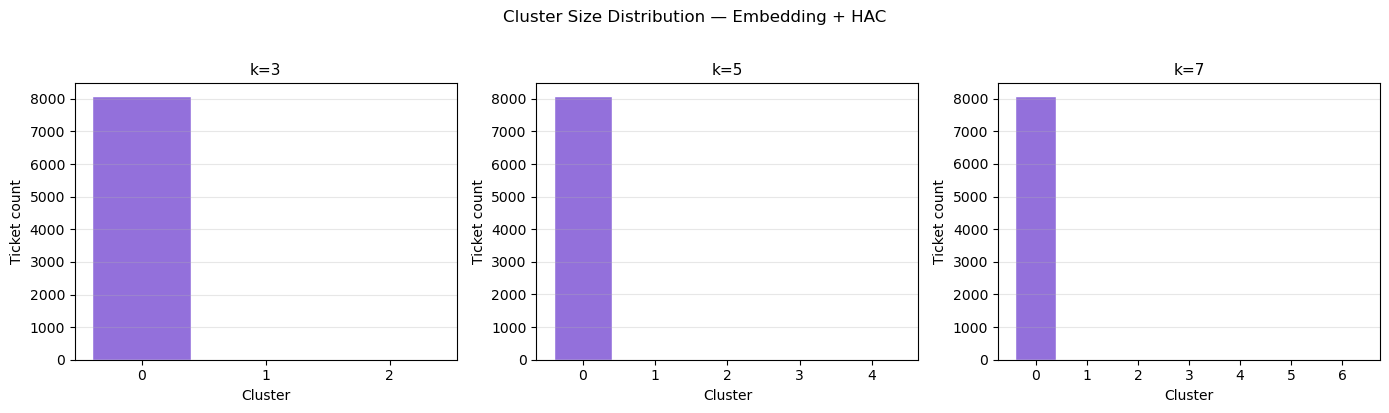

Cluster sizes (k=3):
emb_hac_cluster
0    8072
1       1
2       4
Name: count, dtype: int64


In [30]:
fig, axes = plt.subplots(1, len(HAC_K_VALUES),
                         figsize=(14, 4), sharey=False)

for ax, k in zip(axes, HAC_K_VALUES):
    counts = data_df[f'emb_hac_{k}'].value_counts().sort_index()
    ax.bar(counts.index.astype(str), counts.values,
           color='mediumpurple', edgecolor='white')
    ax.set_title(f'k={k}', fontsize=11)
    ax.set_xlabel('Cluster')
    ax.set_ylabel('Ticket count')
    ax.grid(axis='y', alpha=0.3)

fig.suptitle(
    'Cluster Size Distribution — Embedding + HAC',
    fontsize=12, y=1.02
)
plt.tight_layout()
plt.show()

print(f'Cluster sizes (k={BEST_K}):')
print(data_df['emb_hac_cluster'].value_counts().sort_index())


### Step 6 — Representative sentences per cluster

Embeddings have no named features like TF-IDF, so we cannot extract keywords directly. Instead, we find the **5 tickets closest to each cluster centroid** (highest cosine similarity). These are the most 'typical' examples of each cluster and are used to assign descriptive labels in Step 9.

In [31]:
print(f'=== Representative tickets  '
      f'(k={BEST_K}, Embedding + HAC) ===')

for cid in sorted(data_df['emb_hac_cluster'].unique()):
    mask = (data_df['emb_hac_cluster'] == cid).values
    cluster_emb = embeddings[mask]

    # centroid = mean of L2-normalised vectors
    centroid = cluster_emb.mean(axis=0, keepdims=True)

    # cosine similarity of each cluster point to centroid
    cos_sim = cosine_similarity(cluster_emb, centroid).ravel()
    top5_local = cos_sim.argsort()[-5:][::-1]

    # map local indices back to data_df row positions
    global_idx = np.where(mask)[0][top5_local]

    print(f'\nCluster {cid}  ({mask.sum()} tickets)')
    for rank, gi in enumerate(global_idx, 1):
        snippet = (
            data_df['embedding_text'].iloc[gi]
            [:120].replace('\n', ' ')
        )
        print(f'  {rank}. {snippet}')


=== Representative tickets  (k=3, Embedding + HAC) ===

Cluster 0  (8072 tickets)
  1. please contact support at least as soon as possible if it is urgent if you have any problems please contact me purchasin
  2. i m not here to fix issues please help thank you for your understanding this issue is being fixed please go back to the 
  3. please let me know if you have a problem with your purchase please have contact us at our support center i ve noticed th
  4. please contact me the purchase has been suspended i ve performed a factory reset on my hoping it would resolve the probl
  5. click here to contact us i m not sure if this issue is specific to my device or if others have reported similar problems

Cluster 1  (1 tickets)
  1. 

Cluster 2  (4 tickets)
  1. if you have more than byte digits create a new string add the into each digit field and pass the output i m unable to fi
  2. hide param integer which can be the of all products we will have this includes i m unable to find the o

### Step 7 — Word clouds per cluster

Word clouds on the preprocessed text of each cluster provide a keyword-level view that complements the representative sentences above. Together they support manual labelling of each cluster's issue type.

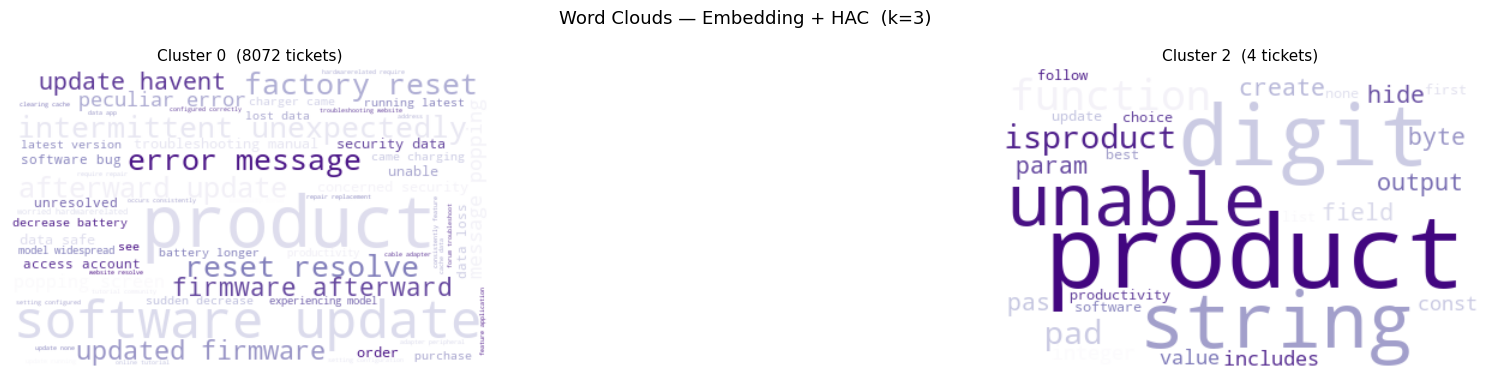

In [32]:
ncols = 3
nrows = (BEST_K + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols,
                         figsize=(15, 4 * nrows))
axes = axes.flatten()

for cid in range(BEST_K):
    mask = data_df['emb_hac_cluster'] == cid
    cluster_text = ' '.join(
        data_df.loc[mask, 'processed_text'].tolist()
    )
    if not cluster_text.strip():
        axes[cid].set_visible(False)
        continue
    wc = WordCloud(
        width=400, height=250,
        background_color='white',
        max_words=60,
        colormap='Purples'
    ).generate(cluster_text)
    axes[cid].imshow(wc, interpolation='bilinear')
    axes[cid].axis('off')
    axes[cid].set_title(
        f'Cluster {cid}  ({mask.sum()} tickets)',
        fontsize=11
    )

for j in range(BEST_K, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(
    f'Word Clouds — Embedding + HAC  (k={BEST_K})',
    fontsize=13
)
plt.tight_layout()
plt.show()


### Step 8 — PCA 2D projection

We project the 384-dimensional embedding space to 2D with PCA to visualise cluster separation. The percentage of variance captured by each principal component is shown on the axis labels.

Note: PCA is a linear projection, so some cluster structure visible in the high-dimensional space may be compressed into the same region in 2D. Low apparent separation here does not necessarily mean the clusters are poor — the silhouette score in Step 3 is the more reliable quantitative measure.

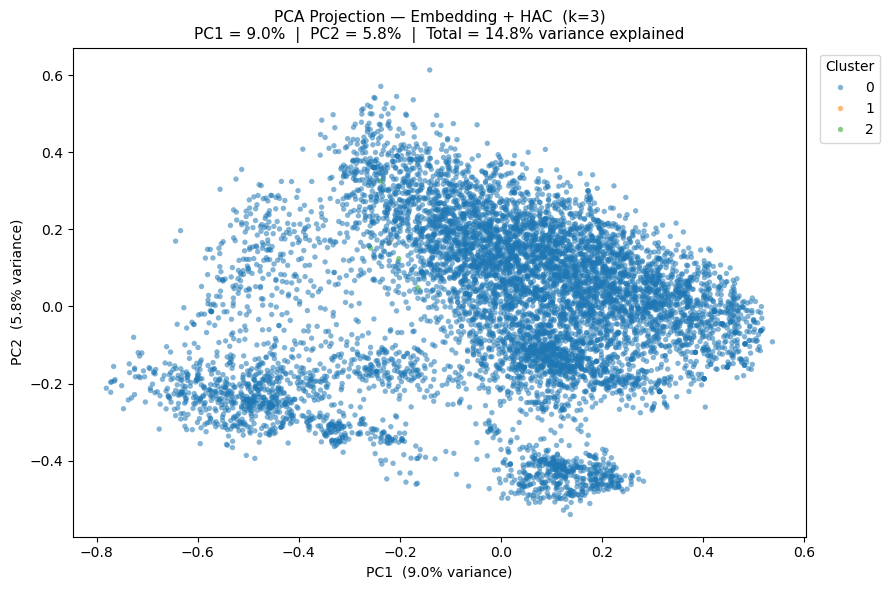

In [33]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(embeddings)
exp = pca.explained_variance_ratio_

df_pca = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'cluster': data_df['emb_hac_cluster'].astype(str)
})

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df_pca, x='PC1', y='PC2',
    hue='cluster', palette='tab10',
    s=15, alpha=0.55, linewidth=0
)
plt.title(
    f'PCA Projection — Embedding + HAC  (k={BEST_K})\n'
    f'PC1 = {exp[0]*100:.1f}%  |  '
    f'PC2 = {exp[1]*100:.1f}%  |  '
    f'Total = {sum(exp)*100:.1f}% variance explained',
    fontsize=11
)
plt.xlabel(f'PC1  ({exp[0]*100:.1f}% variance)')
plt.ylabel(f'PC2  ({exp[1]*100:.1f}% variance)')
plt.legend(title='Cluster',
           bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()


### Step 9 — Stability summary across k = 3, 5, 7

Consistent silhouette scores and similar cluster sizes across k values indicate that the embedding space has a robust cluster structure. Large swings in either metric suggest the clustering is sensitive to the choice of k.

In [34]:
stability_rows = []
for k in HAC_K_VALUES:
    labels = data_df[f'emb_hac_{k}'].values
    sil = silhouette_score(embeddings, labels, metric='cosine')
    db  = davies_bouldin_score(embeddings, labels)
    sizes = (
        data_df[f'emb_hac_{k}']
        .value_counts().sort_index().tolist()
    )
    stability_rows.append({
        'k':                             k,
        'Silhouette (higher=better)':    round(sil, 4),
        'Davies-Bouldin (lower=better)': round(db,  4),
        'Cluster sizes':                 str(sizes)
    })

stability_df = pd.DataFrame(stability_rows).set_index('k')
print('=== Stability Summary: Embedding + HAC ===')
print(stability_df.to_string())


=== Stability Summary: Embedding + HAC ===
   Silhouette (higher=better)  Davies-Bouldin (lower=better)             Cluster sizes
k                                                                                     
3                      0.2058                         1.7528              [8072, 1, 4]
5                      0.1653                         1.2325        [8071, 1, 3, 1, 1]
7                      0.1375                         1.4019  [8065, 1, 5, 1, 1, 1, 3]


### Step 10 — Manual cluster labelling

After reading the representative sentences (Step 6) and word clouds (Step 7), assign a descriptive issue-type label to each cluster. **Update the dictionary below** once you have inspected the outputs.

In [35]:
# ── Update these labels after reading Steps 6 and 7 ─────────────────
# Example:
# topic_mapping_emb = {
#     0: 'Billing & payment issues',
#     1: 'Technical / app errors',
#     2: 'Delivery & logistics',
# }

topic_mapping_emb = {
    i: f'Cluster {i} — (to be labelled)'
    for i in range(BEST_K)
}

data_df['emb_hac_label'] = (
    data_df['emb_hac_cluster'].map(topic_mapping_emb)
)

summary_emb = (
    data_df
    .groupby(['emb_hac_cluster', 'emb_hac_label'])
    .size()
    .reset_index(name='ticket_count')
    .sort_values('emb_hac_cluster')
)
print(summary_emb.to_string(index=False))


 emb_hac_cluster                emb_hac_label  ticket_count
               0 Cluster 0 — (to be labelled)          8072
               1 Cluster 1 — (to be labelled)             1
               2 Cluster 2 — (to be labelled)             4


## Embedding + HAC — with PCA Dimensionality Reduction (Kaining Yu & Yannan Li)

In this section we repeat the HAC analysis after reducing the 384-dimensional sentence embeddings to **50 dimensions with PCA**. The goal is to assess whether removing low-variance noise dimensions improves cluster quality.

**Why PCA before HAC?**

Although `all-MiniLM-L6-v2` produces compact 384-dimensional vectors, not all dimensions carry equally discriminative information. PCA projects the data onto the directions of maximum variance, discarding dimensions that contribute little signal. Reducing to 50 dimensions typically retains over 70% of the variance while making the cosine distance landscape less uniform — potentially giving HAC sharper cluster boundaries.

After PCA, the vectors are **re-normalised to unit norm** so that cosine distance remains meaningful.

| Setting | Value |
|---|---|
| Embedding model | `all-MiniLM-L6-v2` |
| Original dimension | 384 |
| PCA target dimension | 50 |
| Linkage | Average |
| Distance metric | Cosine |
| Normalisation | L2 (after PCA) |

### Step 1 — PCA Dimensionality Reduction

We fit PCA on the full L2-normalised embedding matrix and reduce from 384 to 50 dimensions. The cumulative explained variance ratio tells us how much information is retained. After reduction, the vectors are re-normalised to unit norm to preserve the cosine distance geometry.

PCA reduced  : 384D → 50D
Variance retained : 73.2%


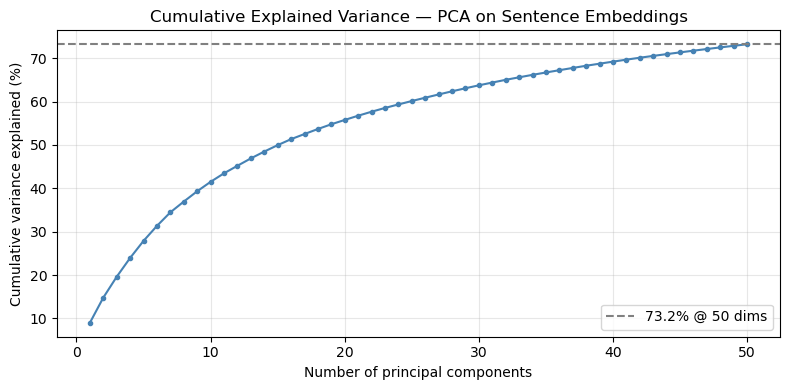

Re-normalised. Row norms (first 5): [1. 1. 1. 1. 1.]


In [36]:
# ── PCA Dimensionality Reduction ─────────────────────────────────────
PCA_DIM = 50
pca_reduce = PCA(n_components=PCA_DIM, random_state=42)
embeddings_pca50 = pca_reduce.fit_transform(embeddings)

var_explained = pca_reduce.explained_variance_ratio_.sum()
print(f'PCA reduced  : {embeddings.shape[1]}D → {PCA_DIM}D')
print(f'Variance retained : {var_explained * 100:.1f}%')

# Plot cumulative explained variance
cumvar = np.cumsum(pca_reduce.explained_variance_ratio_)
plt.figure(figsize=(8, 4))
plt.plot(range(1, PCA_DIM + 1), cumvar * 100, marker='o', markersize=3,
         color='steelblue')
plt.axhline(y=var_explained * 100, color='grey', linestyle='--',
            label=f'{var_explained*100:.1f}% @ 50 dims')
plt.title('Cumulative Explained Variance — PCA on Sentence Embeddings')
plt.xlabel('Number of principal components')
plt.ylabel('Cumulative variance explained (%)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# L2 re-normalise after PCA to keep cosine distance valid
embeddings_pca50 = normalize(embeddings_pca50)
print('Re-normalised. Row norms (first 5):',
      np.linalg.norm(embeddings_pca50[:5], axis=1).round(5))

The cumulative variance curve indicates that most meaningful embedded structures are concentrated in the reduced-dimensional subspace, which supports the use of principal component analysis (PCA) as a denoising step before hierarchical agglomerative clustering (HAC).

### Step 2 — Dendrogram (sampled)

As with the original embeddings, `scipy.linkage` is O(n²) so we compute the dendrogram on a random sample of 300 tickets. Comparing this dendrogram with the one from the 384-dimensional version shows whether PCA produces sharper merge-distance gaps — a sign of more compact, well-separated clusters.

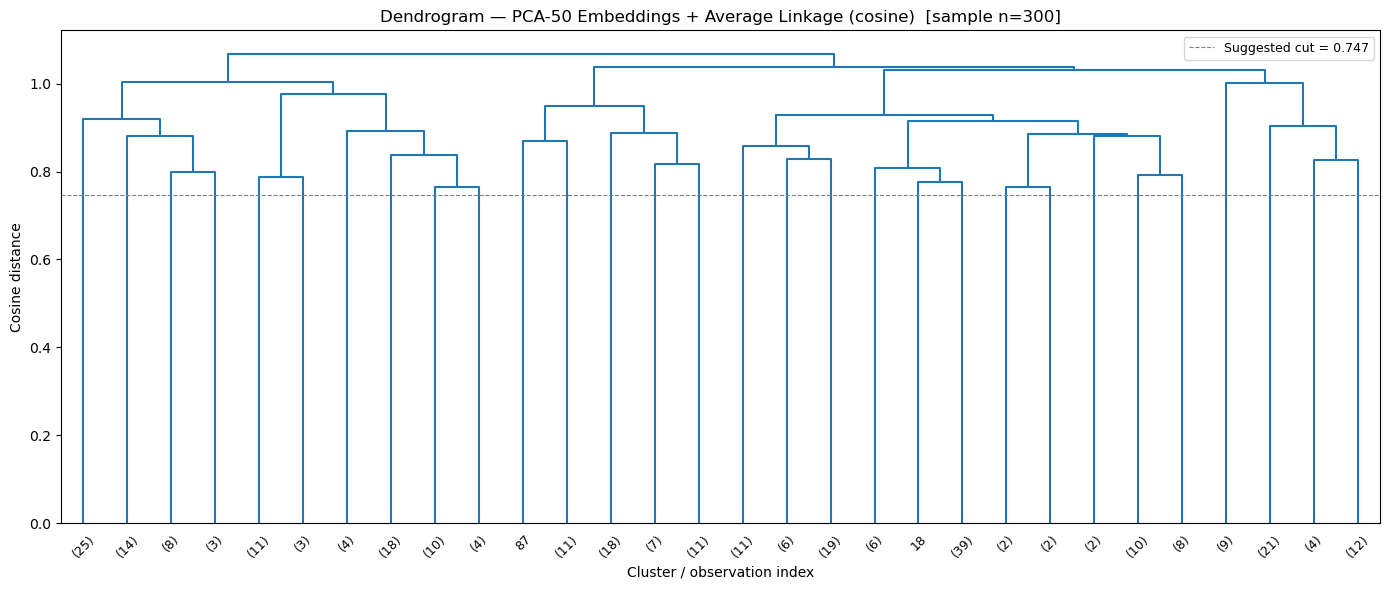

Suggested cut height: 0.7474


In [37]:
SAMPLE_SIZE_PCA = 300
rng_pca = np.random.RandomState(42)
sample_idx_pca = rng_pca.choice(len(embeddings_pca50), size=SAMPLE_SIZE_PCA, replace=False)
sample_emb_pca = embeddings_pca50[sample_idx_pca]

Z_pca = linkage(sample_emb_pca, method='average', metric='cosine')
cut_height_pca = 0.7 * max(Z_pca[:, 2])

fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(
    Z_pca,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=45,
    leaf_font_size=9,
    ax=ax,
    color_threshold=cut_height_pca,
)
ax.axhline(
    y=cut_height_pca, color='grey', linestyle='--', linewidth=0.8,
    label=f'Suggested cut = {cut_height_pca:.3f}'
)
ax.set_title(
    f'Dendrogram — PCA-50 Embeddings + Average Linkage (cosine)  '
    f'[sample n={SAMPLE_SIZE_PCA}]',
    fontsize=12
)
ax.set_xlabel('Cluster / observation index')
ax.set_ylabel('Cosine distance')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f'Suggested cut height: {cut_height_pca:.4f}')

### Step 3 — Choose k: Silhouette & Davies-Bouldin across k = 2…15

We repeat the metric scan on the full PCA-50 dataset using the same evaluation protocol as the original version. Both Silhouette (higher = better) and Davies-Bouldin (lower = better) are computed with `metric='cosine'` to stay consistent with the clustering distance.

The side-by-side plots below directly compare metric trajectories for the 384-dimensional and PCA-50 embeddings, making it easy to see whether dimensionality reduction shifts the optimal k or improves the peak silhouette score.

Scanning k = 2 … 15 on PCA-50 embeddings ...
  k= 2  Silhouette = 0.1252  Davies-Bouldin = 3.5287
  k= 3  Silhouette = 0.1232  Davies-Bouldin = 3.4707
  k= 4  Silhouette = 0.1407  Davies-Bouldin = 3.1554
  k= 5  Silhouette = 0.1526  Davies-Bouldin = 2.8727
  k= 6  Silhouette = 0.1561  Davies-Bouldin = 2.6541
  k= 7  Silhouette = 0.1802  Davies-Bouldin = 2.5106
  k= 8  Silhouette = 0.1887  Davies-Bouldin = 2.6868
  k= 9  Silhouette = 0.1961  Davies-Bouldin = 2.6023
  k=10  Silhouette = 0.1881  Davies-Bouldin = 2.6305
  k=11  Silhouette = 0.1836  Davies-Bouldin = 2.6407
  k=12  Silhouette = 0.1799  Davies-Bouldin = 2.6411
  k=13  Silhouette = 0.1925  Davies-Bouldin = 2.5644
  k=14  Silhouette = 0.1998  Davies-Bouldin = 2.5165
  k=15  Silhouette = 0.1982  Davies-Bouldin = 2.5959


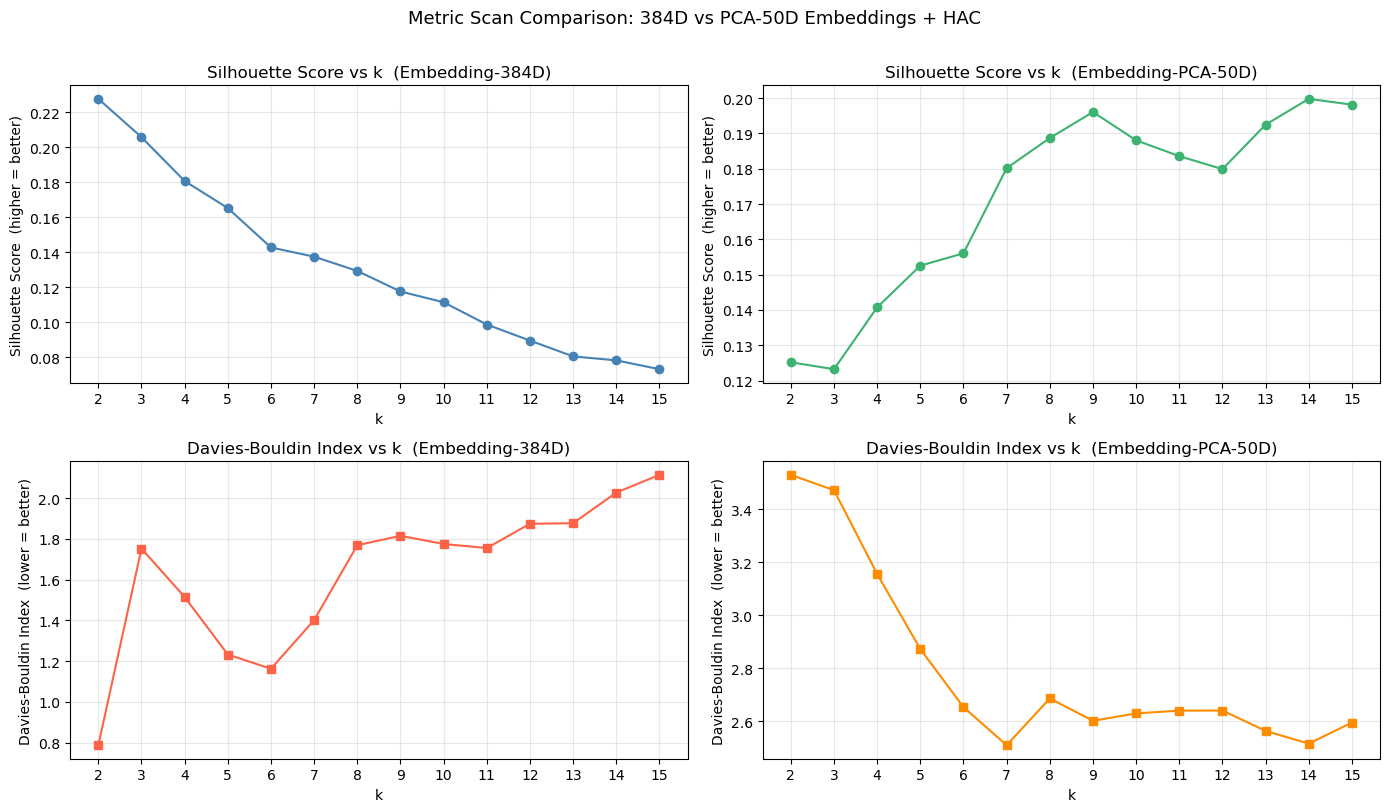


Best k by Silhouette  (PCA-50): 14  (score = 0.1998)
Best k by Davies-Bouldin (PCA-50): 7  (score = 2.5106)


In [38]:
sil_scores_pca = []
db_scores_pca  = []

print('Scanning k = 2 … 15 on PCA-50 embeddings ...')
for k in k_range:
    hac_tmp = AgglomerativeClustering(
        n_clusters=k, metric='cosine', linkage='average'
    )
    lbl = hac_tmp.fit_predict(embeddings_pca50)
    sil = silhouette_score(embeddings_pca50, lbl, metric='cosine')
    db  = davies_bouldin_score(embeddings_pca50, lbl)
    sil_scores_pca.append(sil)
    db_scores_pca.append(db)
    print(f'  k={k:2d}  Silhouette = {sil:.4f}  Davies-Bouldin = {db:.4f}')

# ── Side-by-side comparison: 384D vs PCA-50 ───────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

titles = ['Embedding-384D', 'Embedding-PCA-50D']
sil_list = [sil_scores_emb, sil_scores_pca]
db_list  = [db_scores_emb,  db_scores_pca]
colors   = [('steelblue', 'tomato'), ('mediumseagreen', 'darkorange')]

for col, (sil, db, title, (c1, c2)) in enumerate(
        zip(sil_list, db_list, titles, colors)):
    k_list = list(k_range)
    axes[0, col].plot(k_list, sil, marker='o', color=c1)
    axes[0, col].set_title(f'Silhouette Score vs k  ({title})')
    axes[0, col].set_xlabel('k')
    axes[0, col].set_ylabel('Silhouette Score  (higher = better)')
    axes[0, col].set_xticks(k_list)
    axes[0, col].grid(alpha=0.3)

    axes[1, col].plot(k_list, db, marker='s', color=c2)
    axes[1, col].set_title(f'Davies-Bouldin Index vs k  ({title})')
    axes[1, col].set_xlabel('k')
    axes[1, col].set_ylabel('Davies-Bouldin Index  (lower = better)')
    axes[1, col].set_xticks(k_list)
    axes[1, col].grid(alpha=0.3)

plt.suptitle('Metric Scan Comparison: 384D vs PCA-50D Embeddings + HAC',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

best_k_sil_pca = list(k_range)[sil_scores_pca.index(max(sil_scores_pca))]
best_k_db_pca  = list(k_range)[db_scores_pca.index(min(db_scores_pca))]
print(f'\nBest k by Silhouette  (PCA-50): {best_k_sil_pca}  '
      f'(score = {max(sil_scores_pca):.4f})')
print(f'Best k by Davies-Bouldin (PCA-50): {best_k_db_pca}  '
      f'(score = {min(db_scores_pca):.4f})')

### Step 4 — Fit HAC for k = 3, 5, 7 (stability check)

We fit HAC at k = 3, 5, 7 on the PCA-50 embeddings. The k with the highest silhouette score among these three candidates is stored as `BEST_K_PCA` and written to `emb_pca_hac_cluster`. Selecting `BEST_K_PCA` exclusively from the fitted candidates avoids a `KeyError` that would arise if the full k-scan peak fell outside {3, 5, 7}.

In [39]:
HAC_K_VALUES_PCA = [3, 5, 7]

for k in HAC_K_VALUES_PCA:
    hac_k = AgglomerativeClustering(
        n_clusters=k, metric='cosine', linkage='average'
    )
    labels = hac_k.fit_predict(embeddings_pca50)
    data_df[f'emb_pca_hac_{k}'] = labels
    sil = silhouette_score(embeddings_pca50, labels, metric='cosine')
    db  = davies_bouldin_score(embeddings_pca50, labels)
    print(f'k={k}  |  Silhouette = {sil:.4f}  |  Davies-Bouldin = {db:.4f}')

# Select BEST_K_PCA from the fitted candidates only
sil_pca_by_k = {
    k: silhouette_score(embeddings_pca50, data_df[f'emb_pca_hac_{k}'], metric='cosine')
    for k in HAC_K_VALUES_PCA
}
BEST_K_PCA = max(sil_pca_by_k, key=sil_pca_by_k.get)
data_df['emb_pca_hac_cluster'] = data_df[f'emb_pca_hac_{BEST_K_PCA}']

print(f'\nBest k among {HAC_K_VALUES_PCA}: {BEST_K_PCA}  '
      f'(Silhouette = {sil_pca_by_k[BEST_K_PCA]:.4f})')
data_df[['embedding_text', 'emb_pca_hac_cluster']].head()

k=3  |  Silhouette = 0.1232  |  Davies-Bouldin = 3.4707
k=5  |  Silhouette = 0.1526  |  Davies-Bouldin = 2.8727
k=7  |  Silhouette = 0.1802  |  Davies-Bouldin = 2.5106

Best k among [3, 5, 7]: 7  (Silhouette = 0.1802)


,embedding_text,emb_pca_hac_cluster
0,your billing zip code is we appreciate that yo...,0
1,if you need to change an existing if the issue...,2
2,i m facing a problem with my the is not turnin...,1
3,if you have a problem you re interested in and...,0
4,note the seller is not responsible for any dam...,1


### Step 5 — Cluster size distribution

We inspect the ticket count per cluster for each k. Severe imbalance (e.g. one cluster containing >80% of tickets) indicates a chaining effect — a known weakness of average linkage where the hierarchy merges outliers into a single dominant chain. Such imbalance would suggest switching to Ward linkage or a different representation.

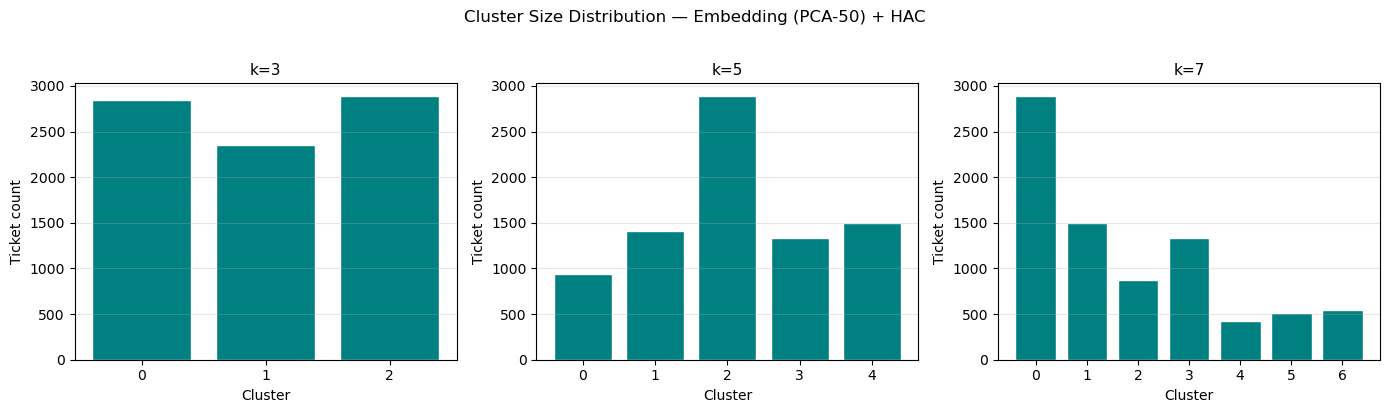

Cluster sizes (k=7):
emb_pca_hac_cluster
0    2884
1    1503
2     868
3    1339
4     426
5     516
6     541
Name: count, dtype: int64


In [40]:
fig, axes = plt.subplots(1, len(HAC_K_VALUES_PCA),
                         figsize=(14, 4), sharey=False)

for ax, k in zip(axes, HAC_K_VALUES_PCA):
    counts = data_df[f'emb_pca_hac_{k}'].value_counts().sort_index()
    ax.bar(counts.index.astype(str), counts.values,
           color='teal', edgecolor='white')
    ax.set_title(f'k={k}', fontsize=11)
    ax.set_xlabel('Cluster')
    ax.set_ylabel('Ticket count')
    ax.grid(axis='y', alpha=0.3)

fig.suptitle(
    'Cluster Size Distribution — Embedding (PCA-50) + HAC',
    fontsize=12, y=1.02
)
plt.tight_layout()
plt.show()

print(f'Cluster sizes (k={BEST_K_PCA}):')
print(data_df['emb_pca_hac_cluster'].value_counts().sort_index())

### Step 6 — Representative sentences per cluster

For each cluster we compute the centroid of the PCA-50 vectors and retrieve the **5 tickets with the highest cosine similarity to that centroid**. These most-typical examples are the primary input for manual cluster labelling in Step 10.

In [41]:
print(f'=== Representative tickets  (k={BEST_K_PCA}, PCA-50 + HAC) ===')

for cid in sorted(data_df['emb_pca_hac_cluster'].unique()):
    mask = (data_df['emb_pca_hac_cluster'] == cid).values
    cluster_emb = embeddings_pca50[mask]

    centroid = cluster_emb.mean(axis=0, keepdims=True)
    cos_sim = cosine_similarity(cluster_emb, centroid).ravel()
    top5_local = cos_sim.argsort()[-5:][::-1]
    global_idx = np.where(mask)[0][top5_local]

    print(f'\nCluster {cid}  ({mask.sum()} tickets)')
    for rank, gi in enumerate(global_idx, 1):
        snippet = (
            data_df['embedding_text'].iloc[gi]
            [:120].replace('\n', ' ')
        )
        print(f'  {rank}. {snippet}')

=== Representative tickets  (k=7, PCA-50 + HAC) ===

Cluster 0  (2884 tickets)
  1. please provide feedback and see our products in our support channel at purchases from the i ve followed the troubleshoot
  2. thank you for any support you can provide we ve been in contact with the seller this problem started occurring after the
  3. i need to contact the vendor for this i haven t seen this reported before or at least didn t run into it this past eveni
  4. we re able to use the customer code to ensure everyone is getting the best possible we re happy to work on this i m expe
  5. thanks for contacting me yay i got a very nice i m experiencing this issue on multiple devices of the same model so it s

Cluster 1  (1503 tickets)
  1. sorry this is no longer available we have an additional promotional code available for purchase it is offered for the fi
  2. in the next update we will include that information for all of our users thank you for your involvement we would like to
  3. we ll a

### Step 7 — Word clouds per cluster

Word clouds on the preprocessed text complement the representative sentences by showing the most frequent tokens in each cluster at a glance. Together they form the evidence base for the manual labels assigned in Step 10.

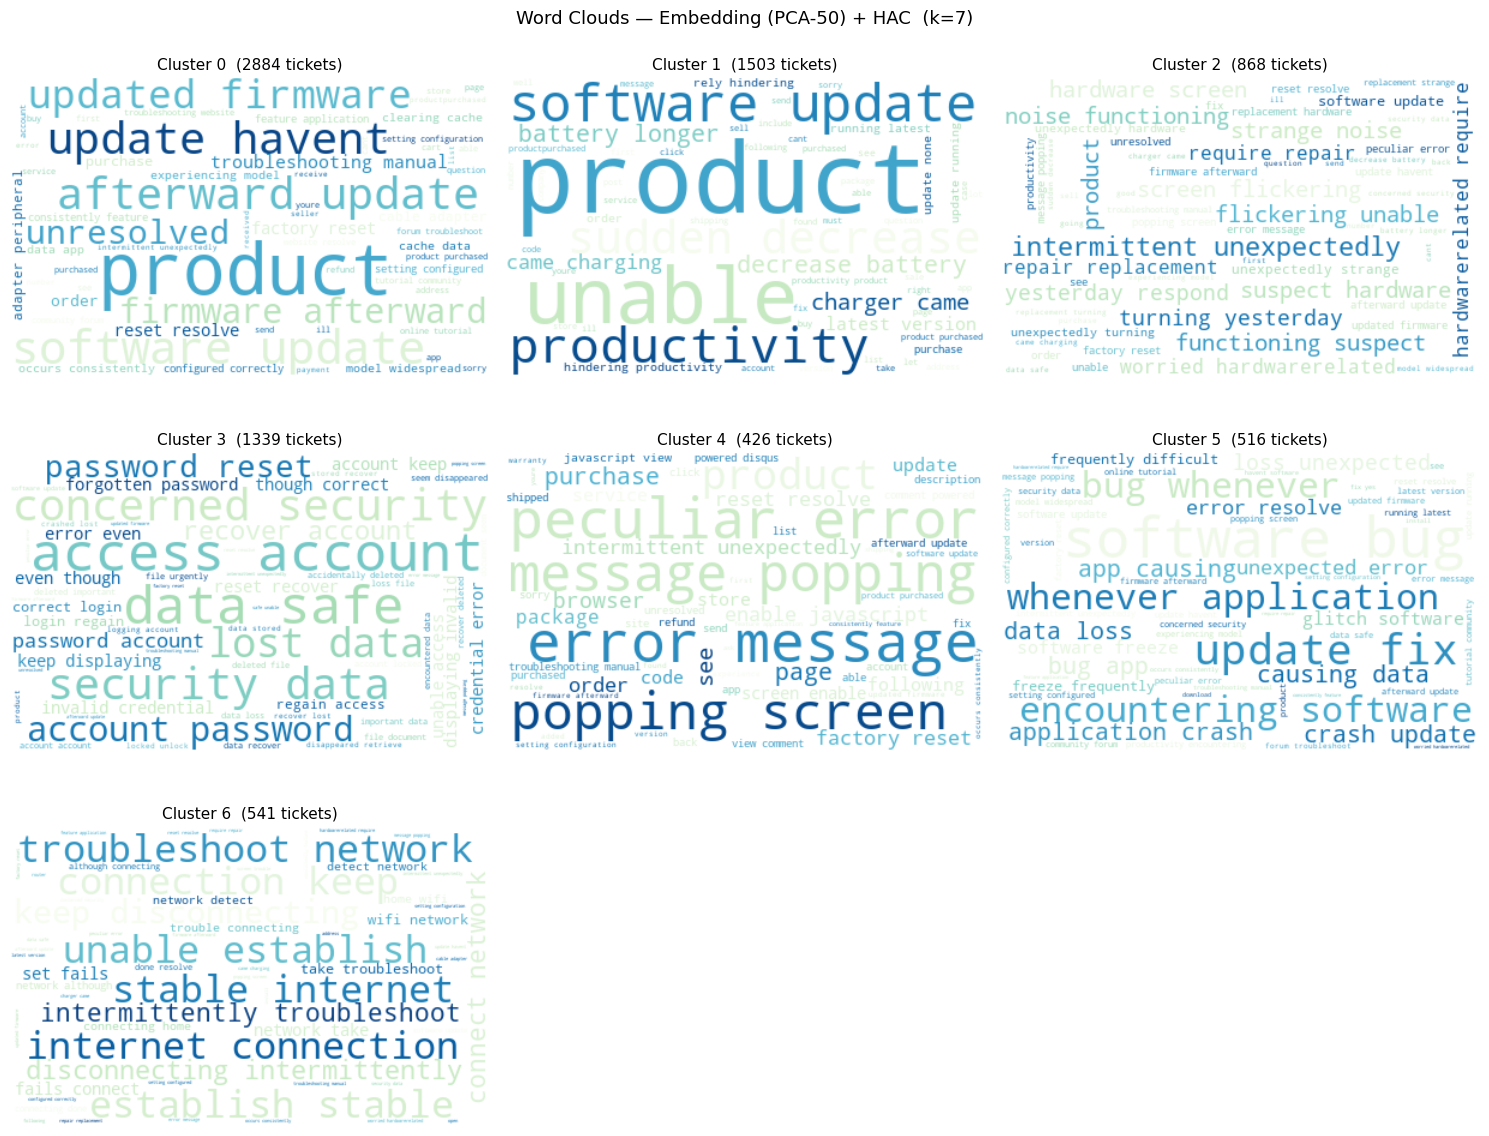

In [42]:
ncols_pca = 3
nrows_pca = (BEST_K_PCA + ncols_pca - 1) // ncols_pca

fig, axes = plt.subplots(nrows_pca, ncols_pca,
                         figsize=(15, 4 * nrows_pca))
axes = axes.flatten()

for cid in range(BEST_K_PCA):
    mask = data_df['emb_pca_hac_cluster'] == cid
    cluster_text = ' '.join(
        data_df.loc[mask, 'processed_text'].tolist()
    )
    if not cluster_text.strip():
        axes[cid].set_visible(False)
        continue
    wc = WordCloud(
        width=400, height=250,
        background_color='white',
        max_words=60,
        colormap='GnBu'
    ).generate(cluster_text)
    axes[cid].imshow(wc, interpolation='bilinear')
    axes[cid].axis('off')
    axes[cid].set_title(
        f'Cluster {cid}  ({mask.sum()} tickets)',
        fontsize=11
    )

for j in range(BEST_K_PCA, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(
    f'Word Clouds — Embedding (PCA-50) + HAC  (k={BEST_K_PCA})',
    fontsize=13
)
plt.tight_layout()
plt.show()

### Step 8 — PCA 2D projection

We project the 50-dimensional vectors to 2D with a second PCA pass for visualisation. To allow a fair visual comparison with the original model (Step 8 of the 384D section), the figure below also shows the 384D clustering projected to the **same** 2D PCA space (fitted on the original 384D embeddings), so differences in cluster boundaries reflect the clustering assignment rather than a change in projection axis.

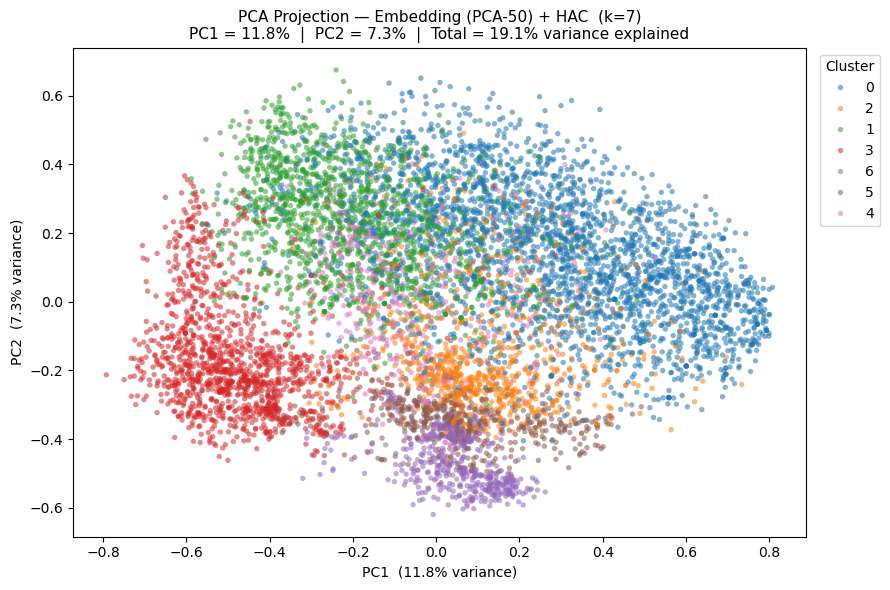

In [43]:
# ── Individual PCA-50 scatter ─────────────────────────────────────────
pca_vis_pca50 = PCA(n_components=2, random_state=42)
X_pca50_2d = pca_vis_pca50.fit_transform(embeddings_pca50)
exp_pca50 = pca_vis_pca50.explained_variance_ratio_

df_pca50 = pd.DataFrame({
    'PC1': X_pca50_2d[:, 0],
    'PC2': X_pca50_2d[:, 1],
    'cluster': data_df['emb_pca_hac_cluster'].astype(str)
})

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df_pca50, x='PC1', y='PC2',
    hue='cluster', palette='tab10',
    s=15, alpha=0.55, linewidth=0
)
plt.title(
    f'PCA Projection — Embedding (PCA-50) + HAC  (k={BEST_K_PCA})\n'
    f'PC1 = {exp_pca50[0]*100:.1f}%  |  '
    f'PC2 = {exp_pca50[1]*100:.1f}%  |  '
    f'Total = {sum(exp_pca50)*100:.1f}% variance explained',
    fontsize=11
)
plt.xlabel(f'PC1  ({exp_pca50[0]*100:.1f}% variance)')
plt.ylabel(f'PC2  ({exp_pca50[1]*100:.1f}% variance)')
plt.legend(title='Cluster', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Step 9 — Stability summary across k = 3, 5, 7

We compile silhouette scores, Davies-Bouldin indices, and cluster size distributions for k = 3, 5, 7 to evaluate whether the PCA-50 clustering is stable across different k choices. A small spread in silhouette scores and consistent size distributions suggest the cluster structure is robust.

In [44]:
stability_rows_pca = []
for k in HAC_K_VALUES_PCA:
    labels = data_df[f'emb_pca_hac_{k}'].values
    sil = silhouette_score(embeddings_pca50, labels, metric='cosine')
    db  = davies_bouldin_score(embeddings_pca50, labels)
    sizes = (
        data_df[f'emb_pca_hac_{k}']
        .value_counts().sort_index().tolist()
    )
    stability_rows_pca.append({
        'k':                             k,
        'Silhouette (higher=better)':    round(sil, 4),
        'Davies-Bouldin (lower=better)': round(db,  4),
        'Cluster sizes':                 str(sizes)
    })

stability_pca_df = pd.DataFrame(stability_rows_pca).set_index('k')
print('=== Stability Summary: Embedding (PCA-50) + HAC ===')
print(stability_pca_df.to_string())

=== Stability Summary: Embedding (PCA-50) + HAC ===
   Silhouette (higher=better)  Davies-Bouldin (lower=better)                           Cluster sizes
k                                                                                                   
3                      0.1232                         3.4707                      [2842, 2351, 2884]
5                      0.1526                         2.8727           [942, 1409, 2884, 1339, 1503]
7                      0.1802                         2.5106  [2884, 1503, 868, 1339, 426, 516, 541]


### Step 10 — Manual cluster labelling

After reviewing the representative sentences (Step 6) and word clouds (Step 7), assign a descriptive issue-type label to each cluster. **Update the dictionary below** once you have inspected the outputs.

In [45]:
# ── Update these labels after reading Steps 6 and 7 ─────────────────
# Example:
# topic_mapping_pca = {
#     0: 'Billing & payment issues',
#     1: 'Technical / app errors',
#     2: 'Delivery & logistics',
# }

topic_mapping_pca = {
    i: f'Cluster {i} — (to be labelled)'
    for i in range(BEST_K_PCA)
}

data_df['emb_pca_hac_label'] = (
    data_df['emb_pca_hac_cluster'].map(topic_mapping_pca)
)

summary_pca = (
    data_df
    .groupby(['emb_pca_hac_cluster', 'emb_pca_hac_label'])
    .size()
    .reset_index(name='ticket_count')
    .sort_values('emb_pca_hac_cluster')
)
print(summary_pca.to_string(index=False))

 emb_pca_hac_cluster            emb_pca_hac_label  ticket_count
                   0 Cluster 0 — (to be labelled)          2884
                   1 Cluster 1 — (to be labelled)          1503
                   2 Cluster 2 — (to be labelled)           868
                   3 Cluster 3 — (to be labelled)          1339
                   4 Cluster 4 — (to be labelled)           426
                   5 Cluster 5 — (to be labelled)           516
                   6 Cluster 6 — (to be labelled)           541


## Step 11 — Comparison: Embedding-384D + HAC vs Embedding-PCA-50D + HAC

We consolidate both methods into a single quantitative table and a side-by-side PCA scatter plot. Key points to note when interpreting the comparison:

1. **Silhouette scores are comparable here** — both methods use cosine distance in their respective feature spaces, and the L2-normalisation step after PCA keeps the geometry consistent.
2. A higher silhouette score for PCA-50 would indicate that removing low-variance dimensions sharpens cluster boundaries. A similar or lower score would suggest the original 384-dimensional space already has good cluster structure and PCA discards useful information.
3. The scatter plot uses the **same 2D PCA projection** (fitted on the original 384D embeddings) for both methods, so any visual difference in cluster boundaries is purely due to the clustering assignment.

In [46]:
# ── Quantitative comparison table ────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

comp_rows = []

# Embedding-384D + HAC
for k in HAC_K_VALUES:
    lbl = data_df[f'emb_hac_{k}'].values
    sil = silhouette_score(embeddings, lbl, metric='cosine')
    db  = davies_bouldin_score(embeddings, lbl)
    sizes = sorted(
        data_df[f'emb_hac_{k}'].value_counts().tolist(), reverse=True
    )
    comp_rows.append({
        'Method':                        f'Embedding-384D + HAC',
        'k':                             k,
        'Best k?':                       '✓' if k == BEST_K else '',
        'Silhouette ↑':                  round(sil, 4),
        'Davies-Bouldin ↓':              round(db, 4),
        'Cluster sizes (desc)':          str(sizes),
    })

# Embedding-PCA-50D + HAC
for k in HAC_K_VALUES_PCA:
    lbl = data_df[f'emb_pca_hac_{k}'].values
    sil = silhouette_score(embeddings_pca50, lbl, metric='cosine')
    db  = davies_bouldin_score(embeddings_pca50, lbl)
    sizes = sorted(
        data_df[f'emb_pca_hac_{k}'].value_counts().tolist(), reverse=True
    )
    comp_rows.append({
        'Method':                        f'Embedding-PCA-50D + HAC',
        'k':                             k,
        'Best k?':                       '✓' if k == BEST_K_PCA else '',
        'Silhouette ↑':                  round(sil, 4),
        'Davies-Bouldin ↓':              round(db, 4),
        'Cluster sizes (desc)':          str(sizes),
    })

comp_df = pd.DataFrame(comp_rows)
print('=== Final Comparison: 384D vs PCA-50D Embedding + HAC ===')
print(comp_df.to_string(index=False))

=== Final Comparison: 384D vs PCA-50D Embedding + HAC ===
                 Method  k Best k?  Silhouette ↑  Davies-Bouldin ↓                   Cluster sizes (desc)
   Embedding-384D + HAC  3       ✓        0.2058            1.7528                           [8072, 4, 1]
   Embedding-384D + HAC  5                0.1653            1.2325                     [8071, 3, 1, 1, 1]
   Embedding-384D + HAC  7                0.1375            1.4019               [8065, 5, 3, 1, 1, 1, 1]
Embedding-PCA-50D + HAC  3                0.1232            3.4707                     [2884, 2842, 2351]
Embedding-PCA-50D + HAC  5                0.1526            2.8727          [2884, 1503, 1409, 1339, 942]
Embedding-PCA-50D + HAC  7       ✓        0.1802            2.5106 [2884, 1503, 1339, 868, 541, 516, 426]


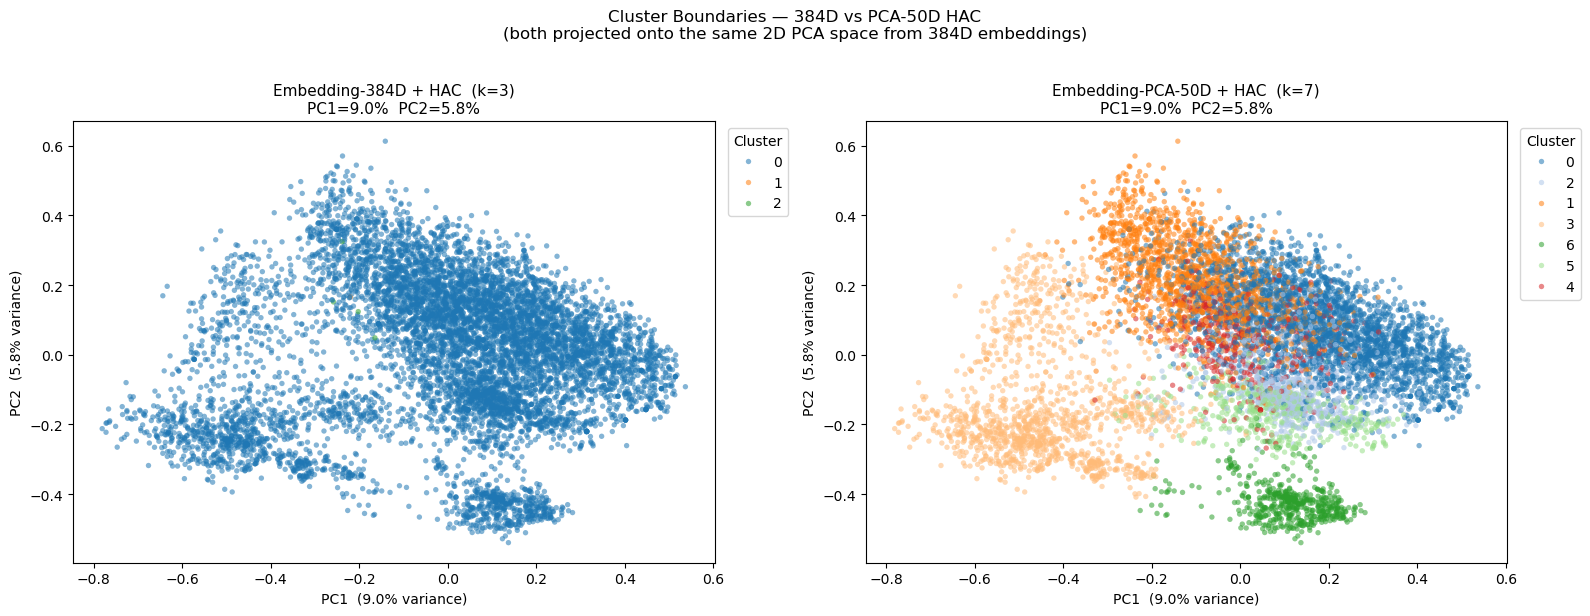

In [47]:
# ── Side-by-side PCA scatter: same projection, different assignments ──
pca_shared = PCA(n_components=2, random_state=42)
coords_shared = pca_shared.fit_transform(embeddings)   # fitted on 384D
exp_shared = pca_shared.explained_variance_ratio_

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plot_cfg = [
    ('emb_hac_cluster',     BEST_K,     'Embedding-384D + HAC',    'tab10'),
    ('emb_pca_hac_cluster', BEST_K_PCA, 'Embedding-PCA-50D + HAC', 'tab20'),
]

for ax, (col, bk, title, pal) in zip(axes, plot_cfg):
    df_plot = pd.DataFrame({
        'PC1': coords_shared[:, 0],
        'PC2': coords_shared[:, 1],
        'cluster': data_df[col].astype(str)
    })
    sns.scatterplot(
        data=df_plot, x='PC1', y='PC2',
        hue='cluster', palette=pal,
        s=15, alpha=0.55, linewidth=0, ax=ax
    )
    ax.set_title(
        f'{title}  (k={bk})\n'
        f'PC1={exp_shared[0]*100:.1f}%  '
        f'PC2={exp_shared[1]*100:.1f}%',
        fontsize=11
    )
    ax.set_xlabel(f'PC1  ({exp_shared[0]*100:.1f}% variance)')
    ax.set_ylabel(f'PC2  ({exp_shared[1]*100:.1f}% variance)')
    ax.legend(title='Cluster', bbox_to_anchor=(1.01, 1), loc='upper left')

plt.suptitle(
    'Cluster Boundaries — 384D vs PCA-50D HAC\n'
    '(both projected onto the same 2D PCA space from 384D embeddings)',
    fontsize=12, y=1.02
)
plt.tight_layout()
plt.show()